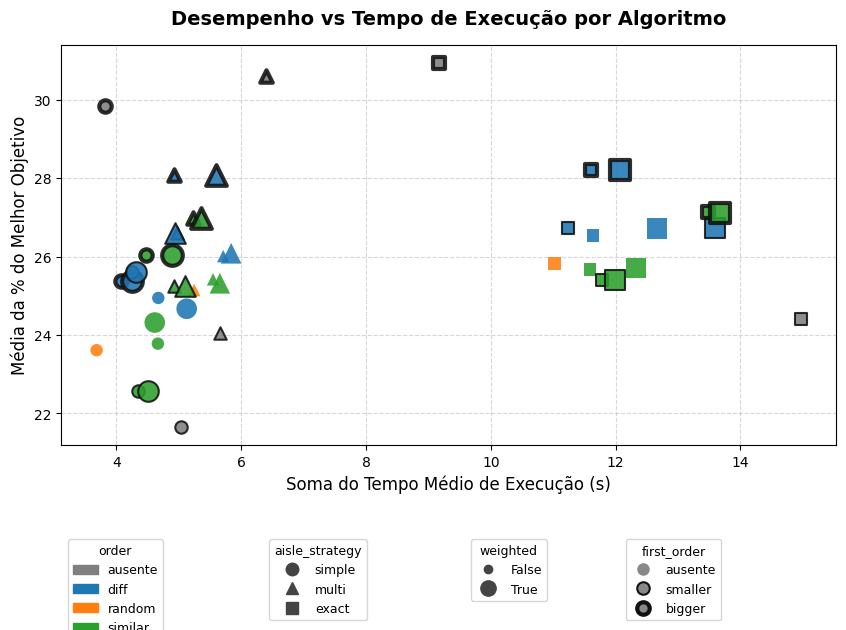

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ─────────────────────────────────────────────
# CAMINHOS E DADOS
# ─────────────────────────────────────────────
project_root = Path.cwd().resolve()
if not (project_root / "results").exists() and (project_root.parent / "results").exists():
    project_root = project_root.parent

file_resultados = project_root / "results" / "simple_all_30_reps_dataset_a" / "summary_a_20260426_093630.csv"
file_baselines  = project_root / "best_solutions" / "best_objectives.csv"

df_resultados = pd.read_csv(file_resultados)
df_baselines  = pd.read_csv(file_baselines)

df_merged = pd.merge(df_resultados, df_baselines, on=["dataset", "instance"], how="inner")
df_merged["pct_best_objective"] = (df_merged["objective_mean"] / df_merged["best_objective"]) * 100

df_grouped = (
    df_merged.groupby("algorithm")
    .agg(
        mean_pct_objective=("pct_best_objective", "mean"),
        sum_exec_time     =("exec_time_mean",      "sum"),
    )
    .reset_index()
)

# ─────────────────────────────────────────────
# PARSING DO NOME → 4 PARÂMETROS
# ─────────────────────────────────────────────
def parse_algorithm(name: str) -> dict:
    tokens = set(name.split("_"))
    return dict(
        order       = next((v for v in ["diff","similar","random","asc","desc"] if v in tokens), "ausente"),
        first_order = next((v for v in ["bigger","smaller"]                     if v in tokens), "ausente"),
        aisle       = next((v for v in ["exact","multi"]                        if v in tokens), "simple"),
        weighted    = "weighted" in tokens,
    )

# ─────────────────────────────────────────────
# MAPEAMENTOS VISUAIS
# ─────────────────────────────────────────────
COLOR_MAP = {
    "diff":    "#1f77b4",
    "similar": "#2ca02c",
    "random":  "#ff7f0e",
    "asc":     "#9467bd",
    "desc":    "#d62728",
    "ausente": "#7f7f7f",
}
MARKER_MAP = {"simple": "o", "multi": "^", "exact": "s"}
SIZE_MAP   = {False: 80, True: 220}
EDGE_MAP   = {
    "ausente": ("none",    0.0),
    "smaller": ("#111111", 1.5),
    "bigger":  ("#111111", 3.0),
}

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(bottom=0.38)   # espaço para rótulo do eixo X + 4 legendas

for _, row in df_grouped.iterrows():
    p  = parse_algorithm(row["algorithm"])
    ec, lw = EDGE_MAP[p["first_order"]]
    ax.scatter(
        row["sum_exec_time"],
        row["mean_pct_objective"],
        c          = COLOR_MAP.get(p["order"], "#333"),
        marker     = MARKER_MAP[p["aisle"]],
        s          = SIZE_MAP[p["weighted"]],
        edgecolors = ec,
        linewidths = lw,
        alpha      = 0.88,
        zorder     = 3,
    )

ax.set_title("Desempenho vs Tempo de Execução por Algoritmo",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Soma do Tempo Médio de Execução (s)", fontsize=12)
ax.set_ylabel("Média da % do Melhor Objetivo", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

# ─────────────────────────────────────────────
# 4 LEGENDAS INDEPENDENTES (uma por parâmetro)
# ─────────────────────────────────────────────

# Só exibe cores que realmente aparecem nos dados
orders_presentes = sorted({parse_algorithm(a)["order"] for a in df_grouped["algorithm"]})

# ── 1. order (cor) ──────────────────────────
handles_order = [
    mpatches.Patch(color=COLOR_MAP[o], label=o)
    for o in orders_presentes
]
leg1 = ax.legend(
    handles=handles_order, title="order",
    loc="upper left", bbox_to_anchor=(0.00, -0.22),
    bbox_transform=ax.transAxes,
    frameon=True, fontsize=9, title_fontsize=9,
)
ax.add_artist(leg1)

# ── 2. aisle_strategy (forma) ───────────────
handles_aisle = [
    mlines.Line2D([], [], color="#444", marker=m, linestyle="None",
                  markersize=9, label=k)
    for k, m in MARKER_MAP.items()
]
leg2 = ax.legend(
    handles=handles_aisle, title="aisle_strategy",
    loc="upper left", bbox_to_anchor=(0.26, -0.22),
    bbox_transform=ax.transAxes,
    frameon=True, fontsize=9, title_fontsize=9,
)
ax.add_artist(leg2)

# ── 3. similarity_weighted (tamanho) ────────
handles_weight = [
    mlines.Line2D([], [], color="#444", marker="o", linestyle="None",
                  markersize=6,  label="False"),
    mlines.Line2D([], [], color="#444", marker="o", linestyle="None",
                  markersize=11, label="True"),
]
leg3 = ax.legend(
    handles=handles_weight, title="weighted",
    loc="upper left", bbox_to_anchor=(0.52, -0.22),
    bbox_transform=ax.transAxes,
    frameon=True, fontsize=9, title_fontsize=9,
)
ax.add_artist(leg3)

# ── 4. first_order (borda) ──────────────────
handles_fo = [
    mlines.Line2D([], [], color="#888", marker="o", linestyle="None",
                  markersize=9, markeredgecolor=ec, markeredgewidth=lw, label=fo)
    for fo, (ec, lw) in EDGE_MAP.items()
]
leg4 = ax.legend(
    handles=handles_fo, title="first_order",
    loc="upper left", bbox_to_anchor=(0.72, -0.22),
    bbox_transform=ax.transAxes,
    frameon=True, fontsize=9, title_fontsize=9,
)
# leg4 é a última — não precisa de add_artist

plt.savefig("grafico_algoritmos.png", dpi=150, bbox_inches="tight")
plt.show()

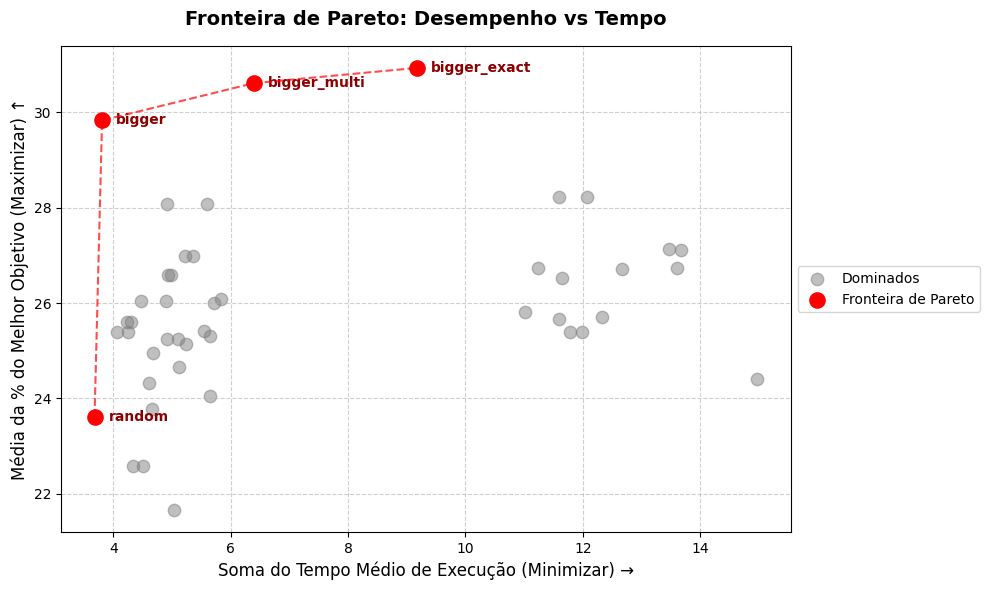


Algoritmos na Fronteira de Pareto (Eficientes):
   algorithm  sum_exec_time  mean_pct_objective
      random       3.681689           23.610675
      bigger       3.809912           29.833032
bigger_multi       6.398359           30.615580
bigger_exact       9.168934           30.933691


In [15]:
# ---------------------------------------------------------
# ETAPA 7: CÁLCULO DA FRONTEIRA DE PARETO
# Regra: Minimizar X (Tempo), Maximizar Y (Porcentagem)
# ---------------------------------------------------------

# Ordena primeiro pelo Tempo (X crescente) e em caso de empate pela Porcentagem (Y decrescente)
df_sorted = df_grouped.sort_values(by=["sum_exec_time", "mean_pct_objective"], ascending=[True, False])

pareto_front = []
max_y_seen = -float('inf')

# Como iteramos do menor tempo para o maior, um ponto só entra na fronteira 
# se ele tiver um % de acerto MAIOR do que o máximo já visto até agora.
for index, row in df_sorted.iterrows():
    if row["mean_pct_objective"] > max_y_seen:
        pareto_front.append(row)
        max_y_seen = row["mean_pct_objective"]

# Converte a lista de dicionários/rows de volta para um DataFrame para facilitar o plot
df_pareto = pd.DataFrame(pareto_front)

# Marca no dataframe original quem é Pareto para facilitar a plotagem visual
df_grouped['is_pareto'] = df_grouped['algorithm'].isin(df_pareto['algorithm'])


# ---------------------------------------------------------
# ETAPA 8: GRÁFICO 2 - DESTAQUE DA FRONTEIRA DE PARETO
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Filtra os dados
df_dominated = df_grouped[~df_grouped['is_pareto']]
df_efficient = df_grouped[df_grouped['is_pareto']]

# 8.1 Plota os algoritmos dominados (em cinza claro, para tirar o foco)
plt.scatter(df_dominated["sum_exec_time"], df_dominated["mean_pct_objective"], 
            c='grey', s=80, alpha=0.5, label='Dominados')

# 8.2 Plota os algoritmos da Fronteira de Pareto (em vermelho, com destaque)
plt.scatter(df_efficient["sum_exec_time"], df_efficient["mean_pct_objective"], 
            c='red', s=120, zorder=5, label='Fronteira de Pareto')

# 8.3 Desenha uma linha ligando a fronteira (garantindo que estão em ordem de tempo)
df_pareto_sorted = df_efficient.sort_values("sum_exec_time")
plt.plot(df_pareto_sorted["sum_exec_time"], df_pareto_sorted["mean_pct_objective"], 
         c='red', linestyle='--', alpha=0.7, zorder=4)

# 8.4 Adiciona os rótulos apenas para elementos da Fronteira de Pareto
for index, row in df_grouped.iterrows():
    if row["is_pareto"]:
        plt.annotate(
            row["algorithm"],
            (row["sum_exec_time"], row["mean_pct_objective"]),
            textcoords="offset points",
            xytext=(10, 0),
            ha="left",
            va="center",
            fontsize=10,
            weight='bold',
            color='darkred'
        )

# Configurações do Gráfico
plt.title("Fronteira de Pareto: Desempenho vs Tempo", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Soma do Tempo Médio de Execução (Minimizar) →", fontsize=12)
plt.ylabel("Média da % do Melhor Objetivo (Maximizar) ↑", fontsize=12)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Opcional: Imprimir os algoritmos ótimos no console
print("\nAlgoritmos na Fronteira de Pareto (Eficientes):")
print(df_pareto[['algorithm', 'sum_exec_time', 'mean_pct_objective']].to_string(index=False))

In [16]:
from pathlib import Path

import pandas as pd

# Reaproveita df_resultados da célula 1; se não existir, recarrega
if "df_resultados" not in globals():
    project_root = Path.cwd().resolve()
    if not (project_root / "results").exists() and (project_root.parent / "results").exists():
        project_root = project_root.parent

    file_resultados = project_root / "results" / "simple_all_30_reps_dataset_a" / "summary_a_20260426_093630.csv"
    df_resultados = pd.read_csv(file_resultados)

summary_alg = (
    df_resultados.groupby("algorithm", as_index=False)
    .agg(
        objective_mean_mean=("objective_mean", "mean"),
        objective_mean_std=("objective_mean", "std"),
        exec_time_mean_mean=("exec_time_mean", "mean"),
        exec_time_mean_std=("exec_time_mean", "std"),
    )
    .fillna(0.0)
)

tabela_final = pd.DataFrame(
    {
        "nome do algoritmo": summary_alg["algorithm"],
        "Media Funcao Objetivo +- desvio": summary_alg.apply(
            lambda r: f"{r['objective_mean_mean']:.4f} +- {r['objective_mean_std']:.4f}", axis=1
        ),
        "Media de Tempo de Execucao (s) +- desvio": summary_alg.apply(
            lambda r: f"{r['exec_time_mean_mean']:.4f} +- {r['exec_time_mean_std']:.4f}", axis=1
        ),
    }
)

display(tabela_final)

latex_table = tabela_final.to_latex(
    index=False,
    caption="Resumo por algoritmo: media e desvio da funcao objetivo e do tempo de execucao",
    label="tab:resumo_algoritmos",
    escape=True,
    column_format="p{0.42\\linewidth}p{0.24\\linewidth}p{0.30\\linewidth}",
)

output_tex = Path("tabela_resumo_algoritmos.tex")
output_tex.write_text(latex_table, encoding="utf-8")

print("LaTeX da tabela:")
print(latex_table)
print(f"Arquivo salvo: {output_tex}")

,nome do algoritmo,Media Funcao Objetivo +- desvio,Media de Tempo de Execucao (s) +- desvio
0,bigger,12.1498 +- 10.7339,0.1905 +- 0.3305
1,bigger_exact,12.5577 +- 11.1228,0.4584 +- 0.8218
2,bigger_multi,12.5180 +- 11.1431,0.3199 +- 0.4117
3,diff,10.8387 +- 9.6355,0.2335 +- 0.3415
4,diff_bigger,10.8370 +- 9.6278,0.2036 +- 0.3237
5,diff_bigger_exact,11.2070 +- 9.7233,0.5800 +- 0.9482
6,diff_bigger_exact_weighted,11.2070 +- 9.7233,0.6039 +- 0.7775
7,diff_bigger_multi,11.1897 +- 9.7337,0.2459 +- 0.3269
8,diff_bigger_multi_weighted,11.1897 +- 9.7337,0.2799 +- 0.3643
9,diff_bigger_weighted,10.8370 +- 9.6278,0.2124 +- 0.3038


LaTeX da tabela:
\begin{table}
\caption{Resumo por algoritmo: media e desvio da funcao objetivo e do tempo de execucao}
\label{tab:resumo_algoritmos}
\begin{tabular}{p{0.42\linewidth}p{0.24\linewidth}p{0.30\linewidth}}
\toprule
nome do algoritmo & Media Funcao Objetivo +- desvio & Media de Tempo de Execucao (s) +- desvio \\
\midrule
bigger & 12.1498 +- 10.7339 & 0.1905 +- 0.3305 \\
bigger\_exact & 12.5577 +- 11.1228 & 0.4584 +- 0.8218 \\
bigger\_multi & 12.5180 +- 11.1431 & 0.3199 +- 0.4117 \\
diff & 10.8387 +- 9.6355 & 0.2335 +- 0.3415 \\
diff\_bigger & 10.8370 +- 9.6278 & 0.2036 +- 0.3237 \\
diff\_bigger\_exact & 11.2070 +- 9.7233 & 0.5800 +- 0.9482 \\
diff\_bigger\_exact\_weighted & 11.2070 +- 9.7233 & 0.6039 +- 0.7775 \\
diff\_bigger\_multi & 11.1897 +- 9.7337 & 0.2459 +- 0.3269 \\
diff\_bigger\_multi\_weighted & 11.1897 +- 9.7337 & 0.2799 +- 0.3643 \\
diff\_bigger\_weighted & 10.8370 +- 9.6278 & 0.2124 +- 0.3038 \\
diff\_exact & 11.1471 +- 9.7755 & 0.5819 +- 0.9379 \\
diff\_exact\